In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datasets import load_dataset

c:\Users\User\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Import Dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

In [4]:
# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
df_US_DA = (
    df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]
    .dropna(subset='salary_year_avg')
    .copy()
)

In [31]:
df_US_DA_exploded = df_US_DA.explode('job_skills')

In [39]:
df_DA_skills = (df_US_DA_exploded
    .groupby('job_skills')['salary_year_avg']
    .agg(['count', 'median'])
).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

df_total_jobs = len(df_US_DA)

df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / df_total_jobs * 100

skill_percent = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


In [62]:
df_technology = df['job_type_skills'].copy()

# Remove duplicates

df_technology = df_technology.drop_duplicates()

# Remove NaN values

df_technology = df_technology.dropna()

# Combine all dictionaries into one

technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row) # Convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value

for key, value in technology_dict.items():
    technology_dict[key] = list(set(value)) # eliminate duplicates by converting to set then back to list
    

In [68]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])
df_technology = df_technology.explode('skills')

In [ ]:
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

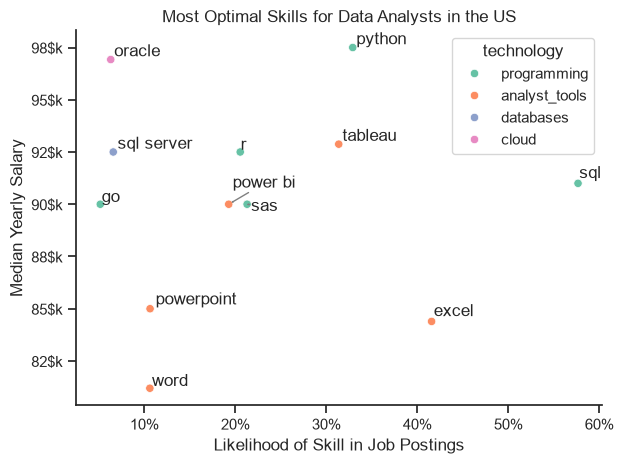

In [89]:
from adjustText import adjust_text
from matplotlib.ticker import FuncFormatter, PercentFormatter, MaxNLocator

#df_plot.plot(kind='scatter', x='skill_percent', y='median_salary')
sns.scatterplot(
    data=df_plot, 
    x='skill_percent',
    y='median_salary',
    hue='technology')

sns.despine()
sns.set_theme(style='ticks')
# Prepare texts for AdjustText

text = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    text.append(plt.text(df_DA_skills_high_demand['skill_percent'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust texts to avoid overlap

adjust_text(text, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title and legend

plt.xlabel('Likelihood of Skill in Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')

ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:.0f}$k'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.yaxis.set_major_locator(MaxNLocator(8))

# Adjust layout and display plot
plt.tight_layout()
plt.show()